<a href="https://colab.research.google.com/github/ikeyareinaldosae/ITC501---Artificial-Intelligence-Applications/blob/main/Weekly%20Labs/Week_4_Linear_Models_with_SciKit_Learn_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 4 Lab - Linear Models with SciKit Learn**

## **Introduction**

During this lab, we are going to be utilising [SciKit-Learn](https://scikit-learn.org/stable/) to train our own Linear algorithms (both regression and classification).

By the end of this lab, you will be able to:

- Import the relevant classes from SciKit-Learn
- Import some data from SciKit-Learn
- Prepare the data for modelling (cleaning/splitting)
- Instantiate the relevant modelling classes
- Train (aka `fit`) the model
- Create a prediction using the newly trained model
- Evaluate the model performance using the relevant performance metrics

In this lab, we will be working only on data for supervised learning:

1. [California Housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) using the [`fetch_california_housing()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) function.
1. [Breast cancer wisconsin (diagnostic) dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset) using the [`load_breast_cancer()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) function.

Let's get started!

## **Preparation**

### Imports

First thing that we want to do is import all the relevant classes and objects that we will be using in our analysis. It is typical that these `import` statements are found at the _top_ of the notebook, and not scattered throughout.

In [1]:
# Import typical python objects
import numpy as np
import pandas as pd

# Import sklearn objects
from sklearn.datasets import (
    fetch_california_housing,
    load_breast_cancer,
)
from sklearn.linear_model import (
    LinearRegression,
    HuberRegressor,
    LogisticRegression,
    RidgeClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    precision_score,
    confusion_matrix,
    PredictionErrorDisplay,
    ConfusionMatrixDisplay,
)

## **Part 1: Regression**

### California Housing dataset

In [2]:
# Load the data
regn = fetch_california_housing()

#### Inspect

Once we load the data, we want to inspect it. Here, we will use the [`dir()`](https://docs.python.org/3/library/functions.html#dir) function, which is built-in to the Python core library. This function will tell us all of the [method](https://docs.python.org/3/glossary.html#term-method)'s and [attribute](https://docs.python.org/3/glossary.html#term-attribute)'s available to us from within an object.

In [3]:
# Check all the options objects contained in the data
print(dir(regn))

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']


Now that we know what is available, let's check each of them.

In [4]:
# Check the description
print(regn.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
# Check the names
print(regn.feature_names)
print(regn.target_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
['MedHouseVal']


In [6]:
# Check the frame
print(regn.frame)
# ... this should be `None`.

None


In [7]:
# Check the feature data
display(
    pd.DataFrame(regn.data, columns=regn.feature_names)
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [8]:
# Check the target data
display(
    pd.DataFrame(regn.target, columns=regn.target_names)
)

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


This is the point where we would implement any data cleaning steps that we may want to do. Like, for example, normalisation, feature engineering, etc. This is also where we would do our typical exploratory data analysis (EDA) to ensure that we thoroughly understand the data that we are dealing with here.

#### Split data

Within the [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function, we can parse in both the `data.data` _and_ the `data.target` objects, and the function will split them both equally. We've defined that the `test_size` should be $20\%$ of the data, which means we are reserving $80\%$ for training. And finally, for reproducability, we define a `random_state` using the value `42`, so that anyone else who runs this same function using the same value will get the same result.

In [ ]:
# !TASK!
# Split the data into training and testing sets
X_regn_train, X_regn_test, y_regn_train, y_regn_test = ...

In [9]:
# !SOLUTION!
# Split the data into training and testing sets
(
    X_regn_train,
    X_regn_test,
    y_regn_train,
    y_regn_test,
) = train_test_split(
    regn.data, regn.target, test_size=0.2, random_state=42
)

We can easily validate that the data has been distributed equally by checking the [`.size`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.size.html) of each object.

In [10]:
# Check dimensions of all objects using Python's `eval()` function
for obj in [
    "X_regn_train",
    "X_regn_test",
    "y_regn_train",
    "y_regn_test",
]:
    print(f"{obj}: {eval(obj).shape}")

X_regn_train: (16512, 8)
X_regn_test: (4128, 8)
y_regn_train: (16512,)
y_regn_test: (4128,)


### **Classic Linear Regression**

#### Create model

When we instantiate the [`LinearRegression()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) class, if we don't specify any parameters, we will just be accepting the default hyperparameter values.

In [ ]:
# !TASK!
# Create (aka 'instantiate') model
model_linreg = ...

In [11]:
# !SOLUTION!
# Create (aka 'instantiate') model
model_linreg = LinearRegression()

#### Train model

When we implement the [`.fit()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit) method for our model, we need to parse _in_ to the model the `X` value and `y` value for our `train`'ing data. Behind the scenes, SciKit-Learn is going to learn the relationship between each of the variables in the `X` object, and how it relates to each of the values in the `y` object.

In [ ]:
# !TASK!
# Train (aka 'fit') model
...

In [12]:
# !SOLUTION!
# Train (aka 'fit') model
model_linreg.fit(X_regn_train, y_regn_train)

LinearRegression()

#### Predict with new data

Now that we have trained our model, we can use it to predict new values on data that it has not seen yet. We do this by using the [`.predict()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict) method, and parse _in_ to the model the `X` value for the `test` data.

In [ ]:
# !TASK!
# Create a prediction
y_pred = ...

In [13]:
# !SOLUTION!
# Create a prediction
y_regn_pred = model_linreg.predict(X_regn_test)

We can then check that the `actual` and the `predicted` values are close to one another placing them both side-by-side (using Python's [`zip()`](https://docs.python.org/3/library/functions.html#zip) function), and then parse'ing that in to a Pandas DataFrame.

In [14]:
# Compare predicted and actual results
display(
    pd.DataFrame(
        zip(y_regn_test, y_regn_pred),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
...,...,...
4123,2.63300,1.991746
4124,2.66800,2.249839
4125,5.00001,4.468770
4126,0.72300,1.187511


#### Measure model performance

Next, we need to measure the performance. Here, we use the [`mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) function from the SciKit-Learn library.

In [15]:
# !SOLUTION!
# Calculate the performance of the prediction
mse = ...
print(f"Mean Squared Error: {mse}")

Mean Squared Error: Ellipsis


In [16]:
# !SOLUTION!
# Calculate the performance of the prediction
mse = mean_squared_error(y_regn_test, y_regn_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.5558915986952422


#### Visualise model performance

Lastly, we can check how closely our model has been able to fit to the data by running the [`.plot()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html#sklearn.metrics.PredictionErrorDisplay.plot) method from the [`PredictionErrorDisplay()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html) class in the SciKit-Learn library.

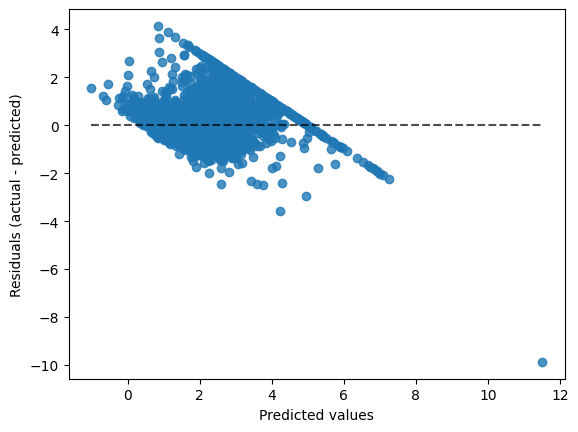

In [17]:
# Visualise the result
error_plot_regn = PredictionErrorDisplay(
    y_true=y_regn_test, y_pred=y_regn_pred
)
error_plot_regn.plot()

Notice here that there is one extreme outlier? That may have an affect on our model, which could potentially explain why we are getting $0.556$ as our MSE value

### **Huber Regression**

Now that we have successfully built and trained a classic Linear Regression algorithm, let's now try to do the same using a different algorithm. Here, we've chosen to use the [`HuberRegressor()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html) algorithm. Why we chose this one (and not one of the many other Regression algorithms available for us to use) is quite simple: it's quite easy to use, and in the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html) it mentions that it is robust to outliers.

In [18]:
# !TASK!
# Instantiate the `HuberRegressor()` class
model_huber = ...

In [19]:
# !SOLUTION!
# Instantiate the `HuberRegressor()` class
model_huber = HuberRegressor()

In [20]:
# !TASK!
# Train the HuberRegressor algorithm
...

Ellipsis

In [21]:
# !SOLUTION!
# Train the HuberRegressor algorithm
model_huber.fit(X_regn_train, y_regn_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


HuberRegressor()

In [22]:
# !TASK!
# Predict on the X_test data
pred_huber = ...

In [23]:
# !SOLUTION!
# Predict on the X_test data
pred_huber = model_huber.predict(X_regn_test)

In [24]:
# Quick check on the predicted values
display(
    pd.DataFrame(
        zip(y_regn_test, pred_huber),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,0.47700,0.901324
1,0.45800,1.346132
2,5.00001,2.238293
3,2.18600,2.706334
4,2.78000,1.959994
...,...,...
4123,2.63300,2.025235
4124,2.66800,1.314726
4125,5.00001,4.489836
4126,0.72300,1.514243


In [ ]:
# !TASK!
# Measure the performance of the model
mse_huber = ...
print(f"Mean Squared Error: {mse_huber}")

In [25]:
# !SOLUTION!
# Measure the performance of the model
mse_huber = mean_squared_error(y_regn_test, pred_huber)
print(f"Mean Squared Error: {mse_huber}")

Mean Squared Error: 0.7175335289286524


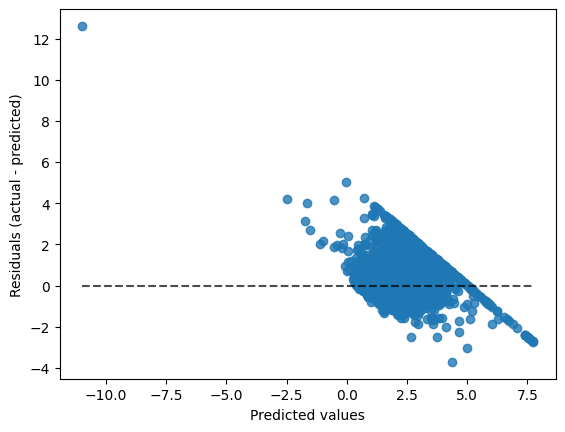

In [26]:
# View the error plot
error_plot_huber = PredictionErrorDisplay(
    y_true=y_regn_test, y_pred=pred_huber
)
error_plot_huber.plot()

Here, you can see that we have followed the _exact_ same process:

1. Instantiation
1. `.fit()`
1. `.predict()`
1. Check performance

That's the beauty of the SciKit-Learn library. It is very very consistent, very clean, and very simple.

Having not changed any of the hyperparameters or tried to improve the performance of the models in any way, we can see straight away that the `HuberRegressor()` algorithm has a performance that is a little different to the `LinearRegression()` algorithm.

## **Part 2: Classification**

### Breast Cancer dataset

In [29]:
# Load the data
clas = load_breast_cancer()

#### Inspect

Once we load the data, we want to inspect it. Here, we will use the [`dir()`](https://docs.python.org/3/library/functions.html#dir) function, which is built-in to the Python coure library. This function will tell us all of the [method](https://docs.python.org/3/glossary.html#term-method)'s and [attribute](https://docs.python.org/3/glossary.html#term-attribute)'s available to us from within an object.

In [30]:
# Check all the options objects contained in the data
print(dir(clas))

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


Now that we know what is available, let's check each of them.

In [31]:
# Check the description
print(clas.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [32]:
# Check the names
print(clas.feature_names)
print(clas.target_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


In [33]:
# Check the frame
print(clas.frame)
# ... this should be `None`.

None


In [34]:
# Check the feature data
display(
    pd.DataFrame(clas.data, columns=clas.feature_names)
)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [35]:
# Check the target data
display(pd.DataFrame(clas.target, columns=["cancer"]))

,cancer
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


This is the point where we would implement any data cleaning steps that we may want to do. Like, for example, normalisation, feature engineering, etc. This is also where we would do our typical exploratory data analysis (EDA) to ensure that we thoroughly understand the data that we are dealing with here.

#### Split data

Within the [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function, we can parse in both the `data.data` _and_ the `data.target` objects, and the function will split them both equally. We've defined that the `test_size` should be $20\%$ of the data, which means we are reserving $80\%$ for training. And finally, for reproducability, we define a `random_state` using the value `42`, so that anyone else who runs this same function using the same value will get the same result.

In [36]:
# !TASK!
# Split the data into training and testing sets
X_clas_train, X_clas_test, y_clas_train, y_clas_test = ...

TypeError: cannot unpack non-iterable ellipsis object

In [37]:
# !SOLUTION!
# Split the data into training and testing sets
(
    X_clas_train,
    X_clas_test,
    y_clas_train,
    y_clas_test,
) = train_test_split(
    clas.data, clas.target, test_size=0.2, random_state=42
)

We can easily validate that the data has been distributed equally by checking the [`.size`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.size.html) of each object.

In [38]:
# Check dimensions of all objects using Python's `eval()` function
for obj in [
    "X_clas_train",
    "X_clas_test",
    "y_clas_train",
    "y_clas_test",
]:
    print(f"{obj}: {eval(obj).shape}")

X_clas_train: (455, 30)
X_clas_test: (114, 30)
y_clas_train: (455,)
y_clas_test: (114,)


### **Classic Logistic Regression**

In [ ]:
# !TASK!
# Instantiate the `HuberRegressor()` class
model_logreg = ...

In [39]:
# !SOLUTION!
# Instantiate the `HuberRegressor()` class
model_logreg = LogisticRegression(random_state=42)

In [ ]:
# !TASK!
# Train the HuberRegressor algorithm
...

In [40]:
# !SOLUTION!
# Train the HuberRegressor algorithm
model_logreg.fit(X_clas_train, y_clas_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
# !TASK!
# Predict on the X_test data
pred_logreg = ...

In [41]:
# !SOLUTION!
# Predict on the X_test data
pred_logreg = model_logreg.predict(X_clas_test)

In [42]:
# Quick check on the predicted values
display(
    pd.DataFrame(
        zip(y_clas_test, pred_logreg),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
...,...,...
109,1,1
110,0,0
111,1,1
112,1,0


In [ ]:
# !TASK!
# Measure the performance of the model
mse_logreg = ...
print(f"Precision Score: {mse_logreg}")

In [43]:
# !SOLUTION!
# Measure the performance of the model
mse_logreg = precision_score(y_clas_test, pred_logreg)
print(f"Precision Score: {mse_logreg}")

Precision Score: 0.9459459459459459


[[39  4]
 [ 1 70]]


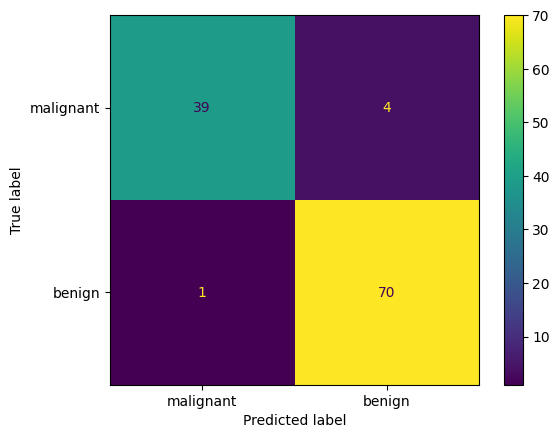

In [ ]:
# View the error plot
cm = confusion_matrix(
    y_true=y_clas_test,
    y_pred=pred_logreg,
    labels=model_logreg.classes_,
)
print(cm)
error_plot_huber = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=clas.target_names
)
error_plot_huber.plot()

### **Ridge Classifier**

In [ ]:
# !TASK!
# Instantiate the `HuberRegressor()` class
model_ridge = ...

In [44]:
# !SOLUTION!
# Instantiate the `HuberRegressor()` class
model_ridge = RidgeClassifier(random_state=42)

In [ ]:
# !TASK!
# Train the HuberRegressor algorithm
...

In [45]:
# !SOLUTION!
# Train the HuberRegressor algorithm
model_ridge.fit(X_clas_train, y_clas_train)

RidgeClassifier(random_state=42)

In [ ]:
# !TASK!
# Predict on the X_test data
pred_ridge = ...

In [46]:
# !SOLUTION!
# Predict on the X_test data
pred_ridge = model_ridge.predict(X_clas_test)

In [47]:
# Quick check on the predicted values
display(
    pd.DataFrame(
        zip(y_clas_test, pred_ridge),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
...,...,...
109,1,1
110,0,0
111,1,1
112,1,1


In [ ]:
# !TASK!
# Measure the performance of the model
mse_ridge = ...
print(f"Precision Score: {mse_ridge}")

In [48]:
# !SOLUTION!
# Measure the performance of the model
mse_ridge = precision_score(y_clas_test, pred_ridge)
print(f"Precision Score: {mse_ridge}")

Precision Score: 0.9459459459459459


[[39  4]
 [ 1 70]]


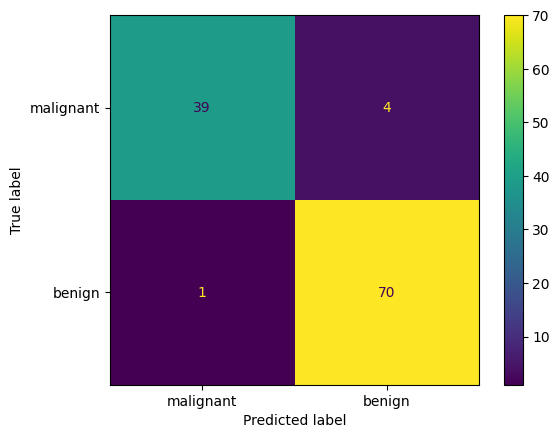

In [49]:
# View the error plot
cm = confusion_matrix(
    y_true=y_clas_test,
    y_pred=pred_ridge,
    labels=model_ridge.classes_,
)
print(cm)
error_plot_huber = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=clas.target_names
)
error_plot_huber.plot()

# Submission
When you are ready to submit please go to `File` -> `Print` -> `Print PDF` and then upload and submit in the Campus Online.

Please save your file to GitHub via: `File` -> `Save a copy in GitHub`